# Position-coded nodal RSAM spatial noise profiles

This notebook replaces the legacy geometry-based stage-80 notebook.

It uses the summary CSV produced by:

```text
70_summarize_position_coded_rsam_windows.ipynb
```

The main additional value beyond notebook 88 is **spatial quantification**:
rather than showing how noise evolves with time, these plots show how the
typical amplitude varies along each profile during selected quiet, elevated,
and active-survey windows.

The notebook avoids unsupported attribution. The 18 May 11:00–13:00 UTC
interval is labelled as an elevated pre-survey period, not as verified logging.

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Configuration

In [2]:
SAM_DIR = Path(
    "/Volumes/tachyon/LBSSP_DATA/nodal_rsam_position_codes"
)
INPUT_FILE = (
    SAM_DIR
    / "noise_profiles"
    / "nodal_noise_window_summary_position_codes.csv"
)
OUT_DIR = SAM_DIR / "noise_profiles" / "spatial_profiles"
OUT_DIR.mkdir(parents=True, exist_ok=True)

NETWORKS = ["T1", "T3"]
COMPONENTS = ["Z", "N", "E"]

METRICS = [
    "median",
    "B4_8",
    "B8_16",
    "B16_32",
    "B32_64",
    "B64_128",
    "B128_240",
]

QUIET_PERIODS = [
    "quiet_2026-05-17_0400_0800",
    "quiet_2026-05-18_0400_0800",
    "quiet_2026-05-19_0400_0800",
]

COMPARISON_PERIODS = [
    "elevated_2026-05-18_1100_1300",
    "survey_T1_1m",
    "survey_T1_2m",
    "survey_nodal_only",
]

PERIOD_LABELS = {
    "quiet_2026-05-17_0400_0800": "Quiet: 17 May 04:00–08:00",
    "quiet_2026-05-18_0400_0800": "Quiet: 18 May 04:00–08:00",
    "quiet_2026-05-19_0400_0800": "Quiet: 19 May 04:00–08:00",
    "elevated_2026-05-18_1100_1300": "Elevated pre-survey: 18 May 11:00–13:00",
    "survey_T1_1m": "T1 1 m survey",
    "survey_T1_2m": "T1 2 m survey",
    "survey_nodal_only": "Nodal-only survey",
}

USE_LOG10 = True
FIGSIZE = (11, 5.5)
DPI = 200

print(f"Input:  {INPUT_FILE}")
print(f"Output: {OUT_DIR}")

Input:  /Volumes/tachyon/LBSSP_DATA/nodal_rsam_position_codes/noise_profiles/nodal_noise_window_summary_position_codes.csv
Output: /Volumes/tachyon/LBSSP_DATA/nodal_rsam_position_codes/noise_profiles/spatial_profiles


## Load the robust window summary

In [3]:
summary = pd.read_csv(
    INPUT_FILE,
    parse_dates=["start_utc", "end_utc"],
)

required_columns = {
    "network",
    "location",
    "component",
    "position_m",
    "period",
    "metric",
    "median_velocity_mps",
}

missing = required_columns - set(summary.columns)
if missing:
    raise KeyError(
        f"Summary file is missing columns: {sorted(missing)}"
    )

summary = summary[
    np.isfinite(summary["median_velocity_mps"])
    & (summary["median_velocity_mps"] > 0)
].copy()

print(f"Rows loaded: {len(summary):,}")
display(summary.head())

Rows loaded: 6,489


,network,station,location,channel,component,position_original_m,period,group,period_label,start_utc,end_utc,metric,n_minutes,median_velocity_mps,position_m
0,T1,2800,N1,DPE,E,28.0,quiet_2026-05-17_0400_0800,quiet,17 May 04:00–08:00 UTC,2026-05-17 04:00:00+00:00,2026-05-17 08:00:00+00:00,B128_240,240,4.229233e-07,28.0
1,T1,2800,N3,DPE,E,28.0,survey_nodal_only,active_survey,"Nodal only, 19 May 12:59–16:02 UTC",2026-05-19 12:59:00+00:00,2026-05-19 16:02:00+00:00,B128_240,70,4.524244e-07,28.0
2,T1,2800,N1,DPE,E,28.0,quiet_2026-05-17_0400_0800,quiet,17 May 04:00–08:00 UTC,2026-05-17 04:00:00+00:00,2026-05-17 08:00:00+00:00,B16_32,240,5.359352e-07,28.0
3,T1,2800,N3,DPE,E,28.0,survey_nodal_only,active_survey,"Nodal only, 19 May 12:59–16:02 UTC",2026-05-19 12:59:00+00:00,2026-05-19 16:02:00+00:00,B16_32,70,2.140494e-06,28.0
4,T1,2800,N1,DPE,E,28.0,quiet_2026-05-17_0400_0800,quiet,17 May 04:00–08:00 UTC,2026-05-17 04:00:00+00:00,2026-05-17 08:00:00+00:00,B32_64,240,2.282904e-07,28.0


## Profile helpers

Quiet reference profiles are calculated as the median of the available quiet
windows at each position. This prevents any single quiet night from dominating
the comparison.

In [4]:
def transform_amplitude(values: pd.Series) -> np.ndarray:
    result = values.to_numpy(dtype=float)

    if USE_LOG10:
        with np.errstate(
            divide="ignore",
            invalid="ignore",
        ):
            result = np.log10(result)

    result[~np.isfinite(result)] = np.nan
    return result


def build_quiet_reference(
    data: pd.DataFrame,
) -> pd.DataFrame:
    quiet = data[
        data["period"].isin(QUIET_PERIODS)
    ]

    return (
        quiet
        .groupby("position_m", as_index=False)
        ["median_velocity_mps"]
        .median()
        .sort_values("position_m")
    )


def profile_for_period(
    data: pd.DataFrame,
    period: str,
) -> pd.DataFrame:
    return (
        data[data["period"] == period]
        .groupby("position_m", as_index=False)
        ["median_velocity_mps"]
        .median()
        .sort_values("position_m")
    )

## Plot quiet and comparison profiles

In [5]:
def plot_spatial_profile(
    summary: pd.DataFrame,
    *,
    network: str,
    component: str,
    metric: str,
    comparison_periods: list[str],
) -> Path | None:
    data = summary[
        (summary["network"] == network)
        & (summary["component"] == component)
        & (summary["metric"] == metric)
    ].copy()

    if data.empty:
        print(
            f"No data for {network} {component} {metric}"
        )
        return None

    quiet = build_quiet_reference(data)

    if quiet.empty:
        print(
            f"No quiet reference for {network} "
            f"{component} {metric}"
        )
        return None

    fig, ax = plt.subplots(
        figsize=FIGSIZE,
        constrained_layout=True,
    )

    ax.plot(
        quiet["position_m"],
        transform_amplitude(
            quiet["median_velocity_mps"]
        ),
        linewidth=2.8,
        marker="o",
        markersize=3.5,
        label="Median quiet reference",
    )

    for period in comparison_periods:
        profile = profile_for_period(
            data,
            period,
        )

        if profile.empty:
            continue

        ax.plot(
            profile["position_m"],
            transform_amplitude(
                profile["median_velocity_mps"]
            ),
            linewidth=1.8,
            marker="o",
            markersize=3,
            label=PERIOD_LABELS.get(period, period),
        )

    ax.set_title(
        f"{network} {component}-component "
        f"spatial noise profile: {metric}"
    )
    ax.set_xlabel("Position along profile (m)")
    ax.set_ylabel(
        (
            f"log10({metric} median velocity [m/s])"
            if USE_LOG10
            else f"{metric} median velocity [m/s]"
        )
    )
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=8)

    outfile = (
        OUT_DIR
        / f"{network}_{component}_{metric}_spatial_profiles.png"
    )
    fig.savefig(
        outfile,
        dpi=DPI,
        bbox_inches="tight",
    )
    plt.show()
    plt.close(fig)

    print(f"Wrote {outfile}")
    return outfile

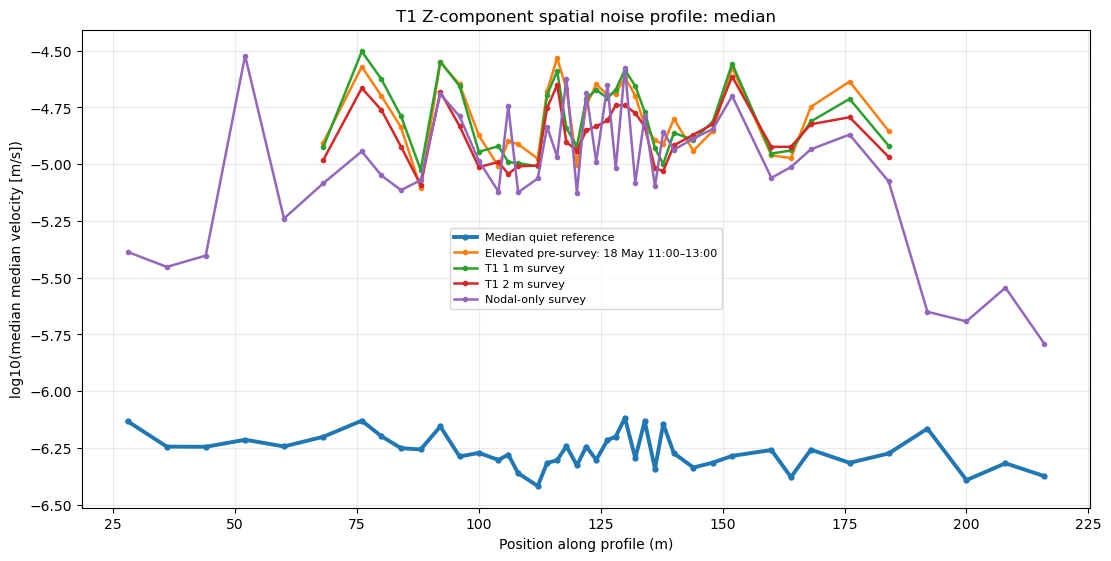

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_rsam_position_codes/noise_profiles/spatial_profiles/T1_Z_median_spatial_profiles.png


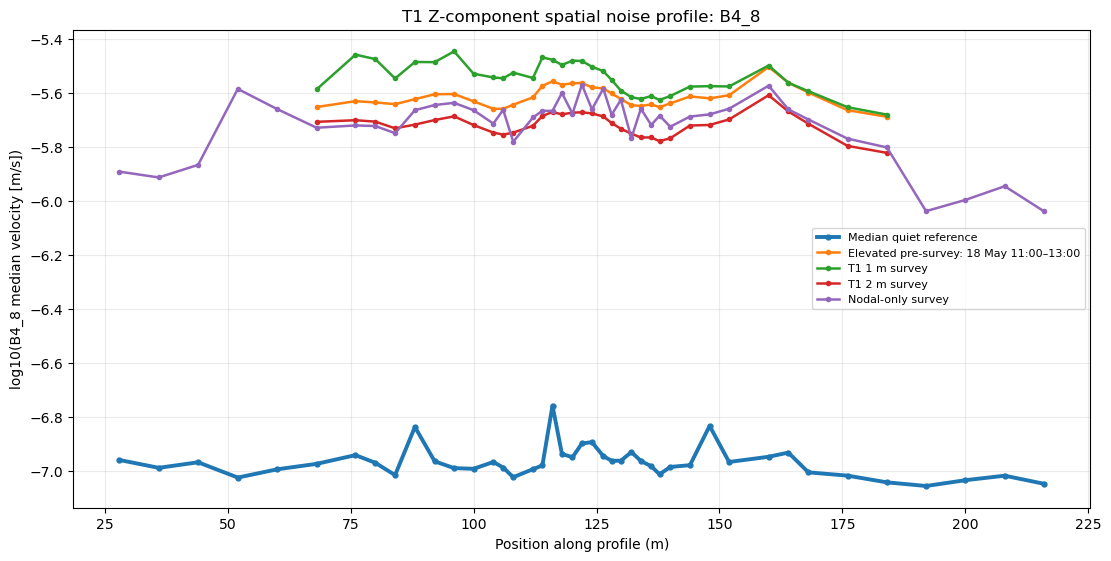

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_rsam_position_codes/noise_profiles/spatial_profiles/T1_Z_B4_8_spatial_profiles.png


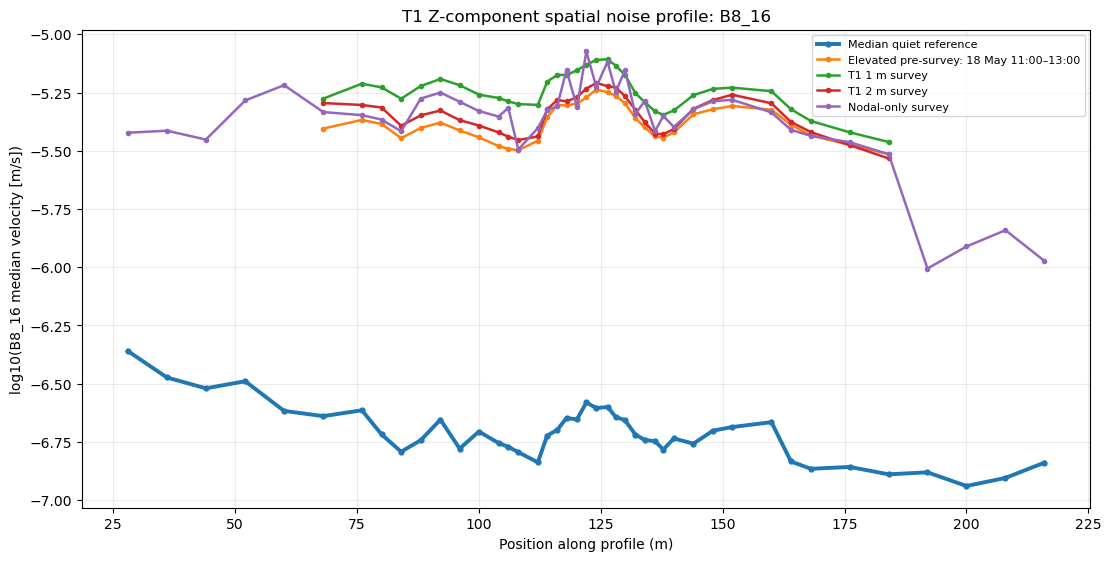

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_rsam_position_codes/noise_profiles/spatial_profiles/T1_Z_B8_16_spatial_profiles.png


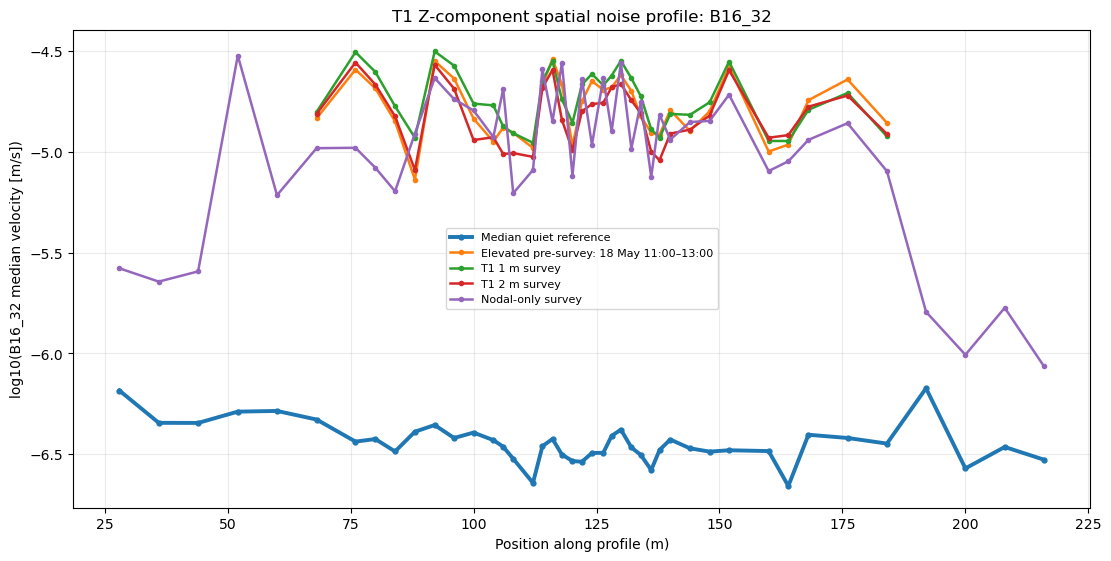

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_rsam_position_codes/noise_profiles/spatial_profiles/T1_Z_B16_32_spatial_profiles.png


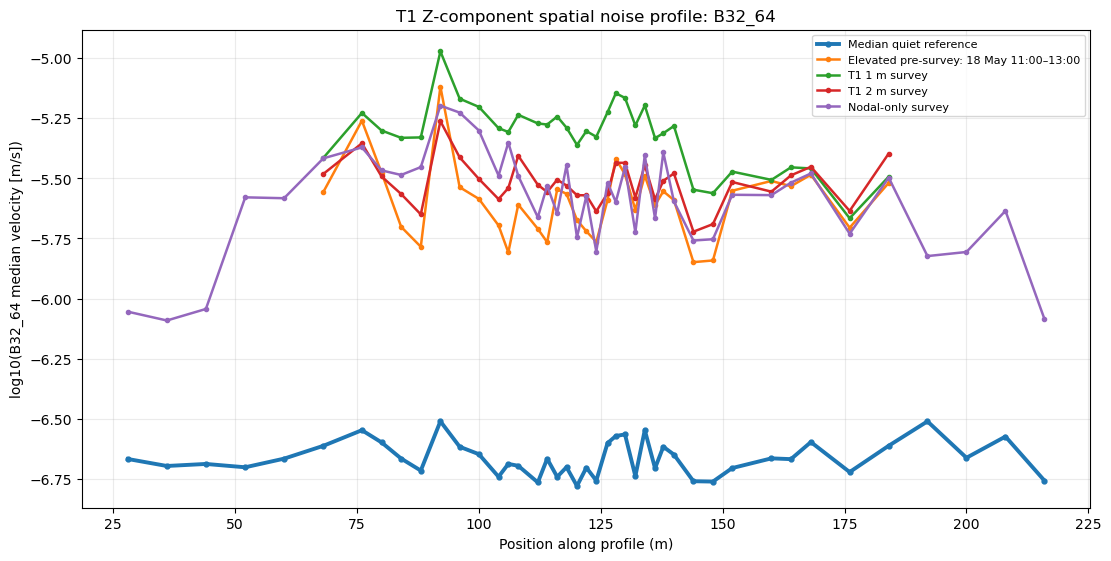

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_rsam_position_codes/noise_profiles/spatial_profiles/T1_Z_B32_64_spatial_profiles.png


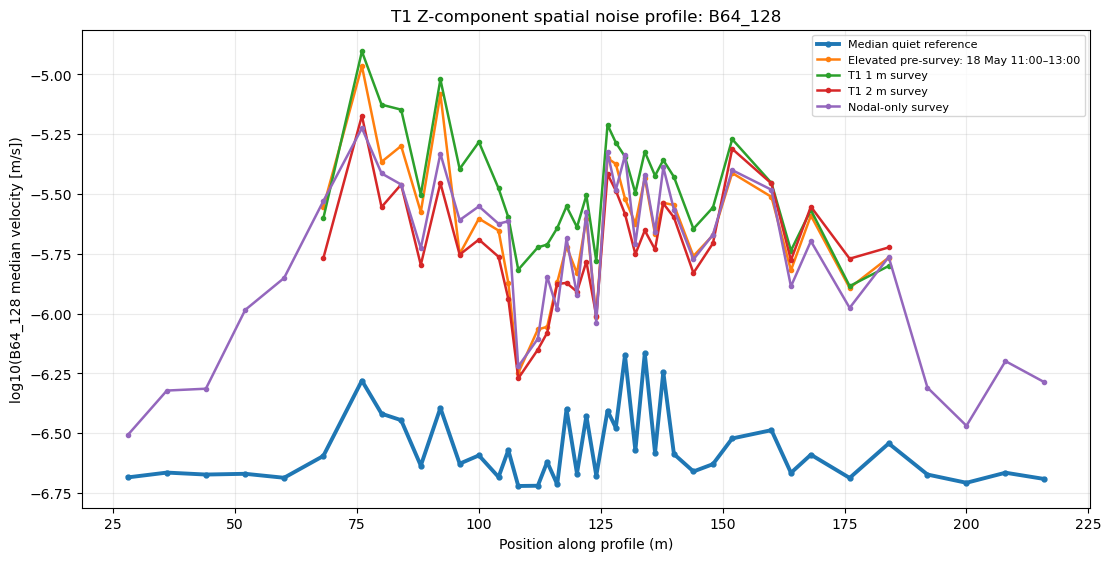

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_rsam_position_codes/noise_profiles/spatial_profiles/T1_Z_B64_128_spatial_profiles.png


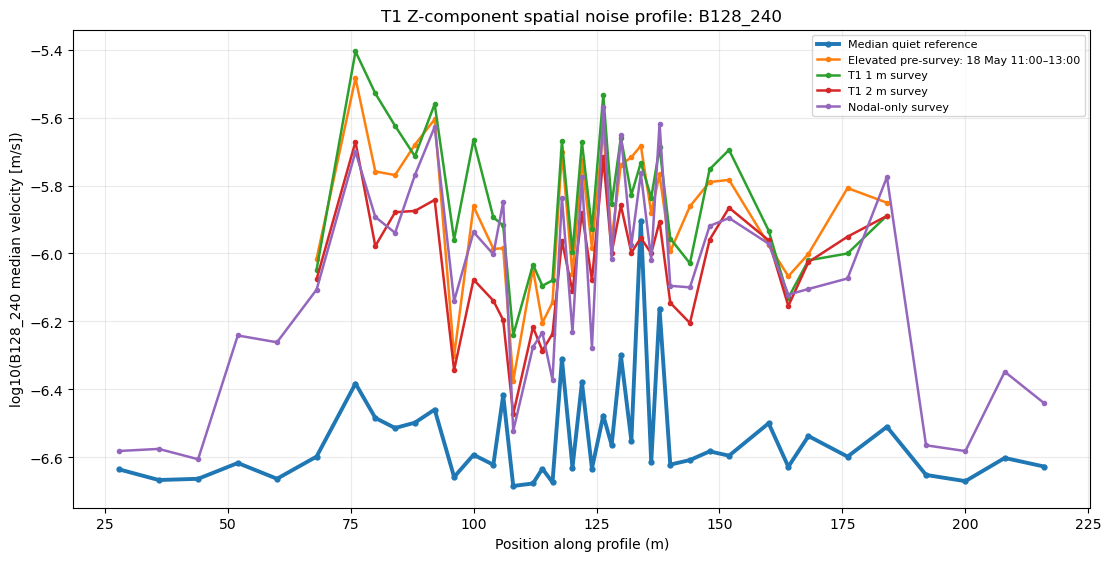

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_rsam_position_codes/noise_profiles/spatial_profiles/T1_Z_B128_240_spatial_profiles.png


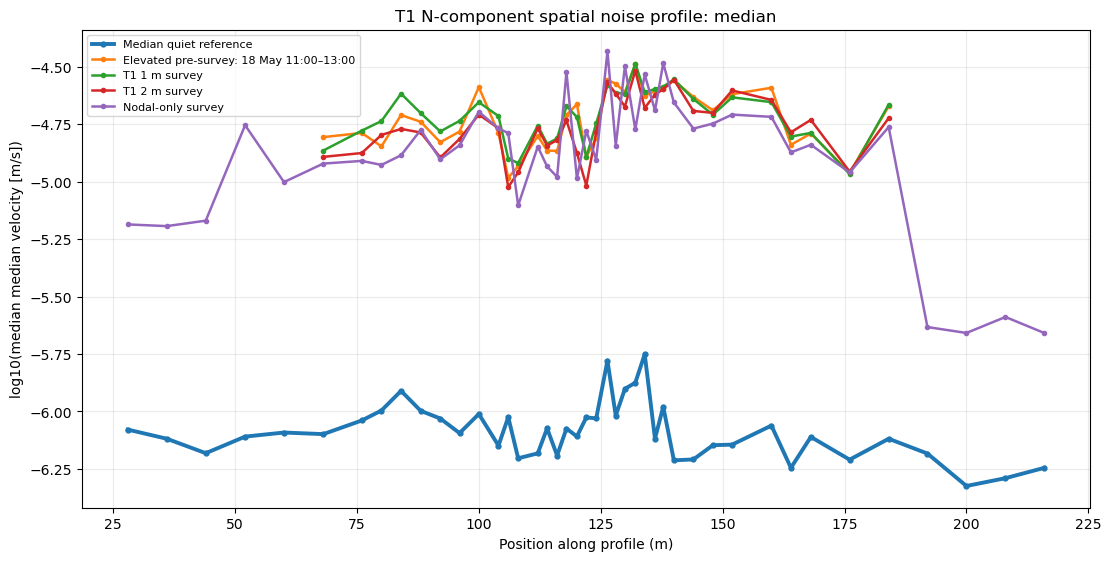

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_rsam_position_codes/noise_profiles/spatial_profiles/T1_N_median_spatial_profiles.png


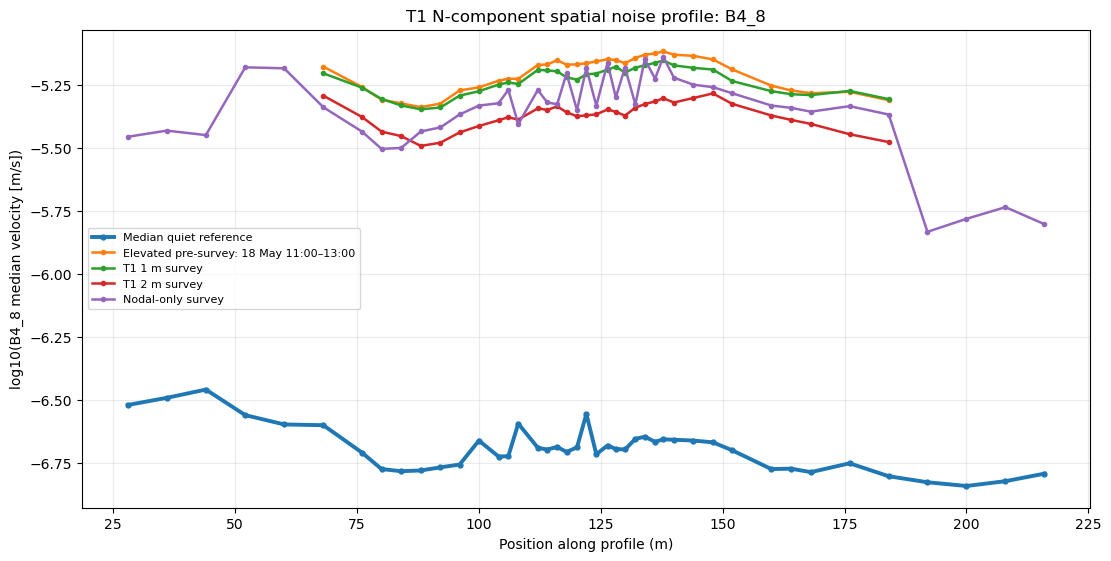

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_rsam_position_codes/noise_profiles/spatial_profiles/T1_N_B4_8_spatial_profiles.png


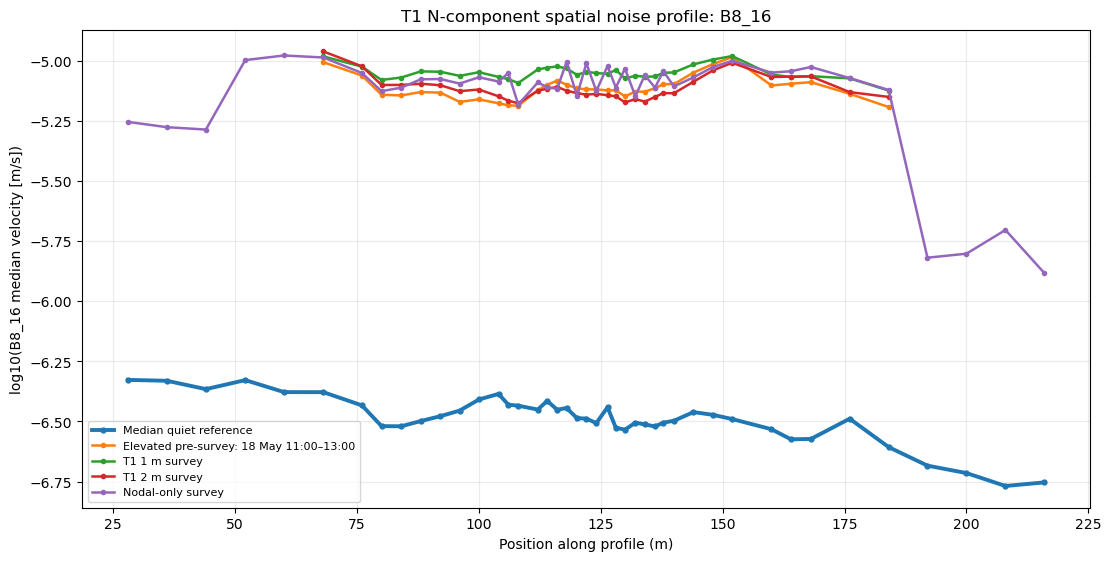

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_rsam_position_codes/noise_profiles/spatial_profiles/T1_N_B8_16_spatial_profiles.png


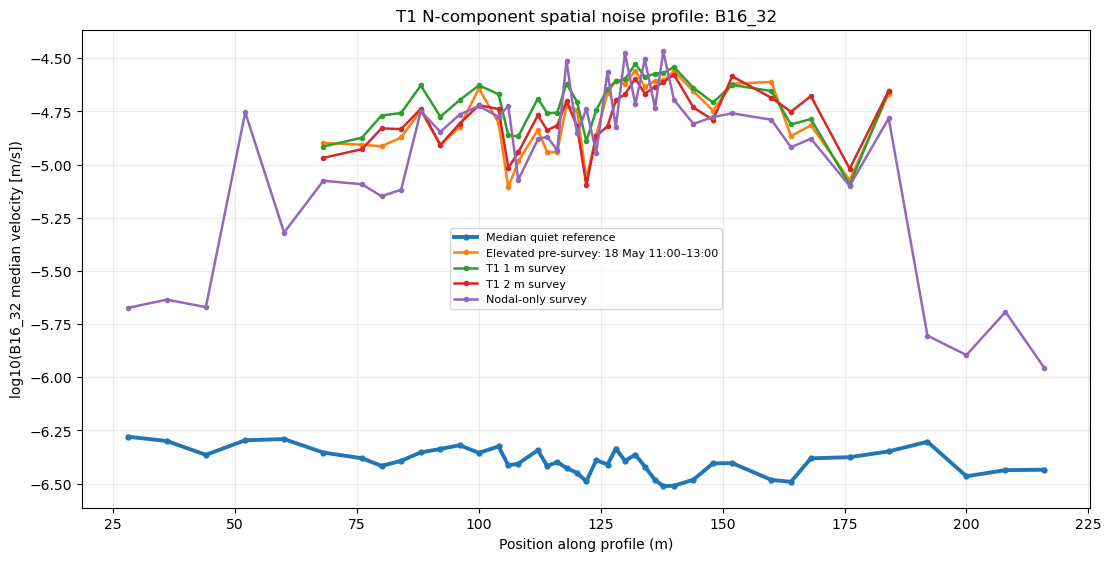

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_rsam_position_codes/noise_profiles/spatial_profiles/T1_N_B16_32_spatial_profiles.png


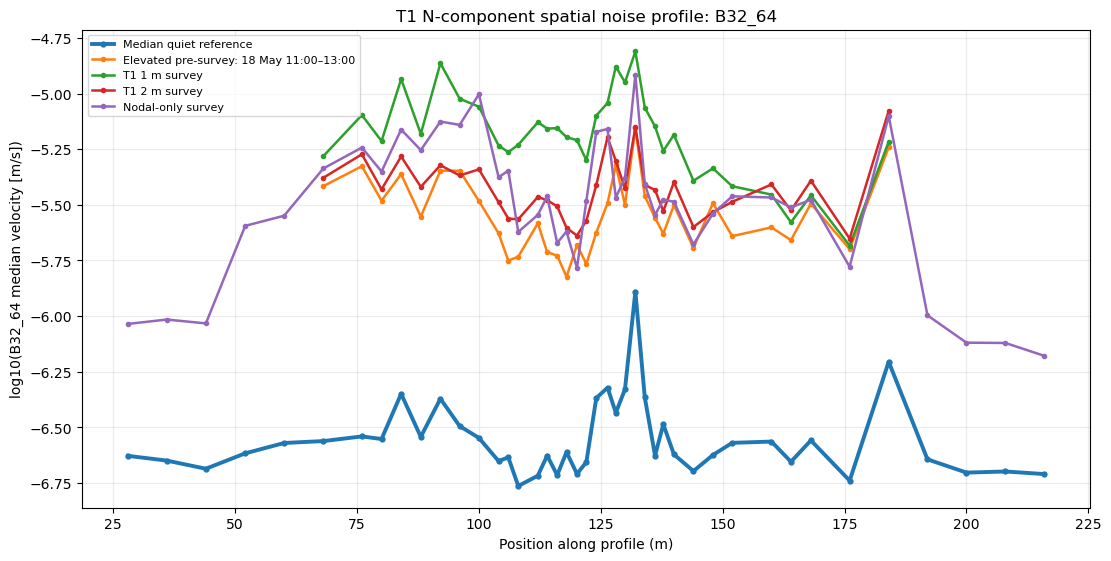

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_rsam_position_codes/noise_profiles/spatial_profiles/T1_N_B32_64_spatial_profiles.png


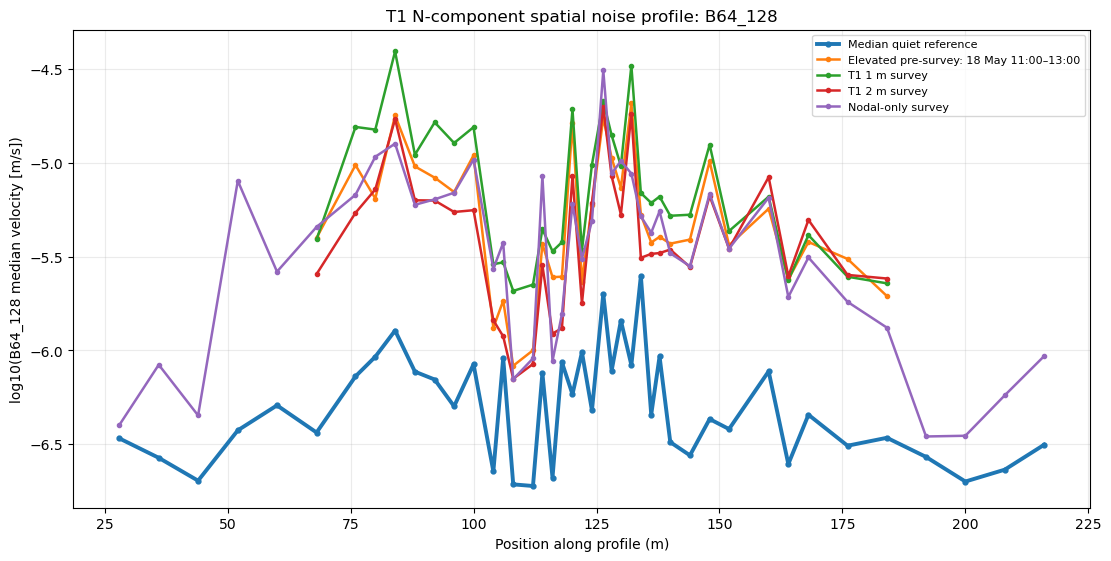

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_rsam_position_codes/noise_profiles/spatial_profiles/T1_N_B64_128_spatial_profiles.png


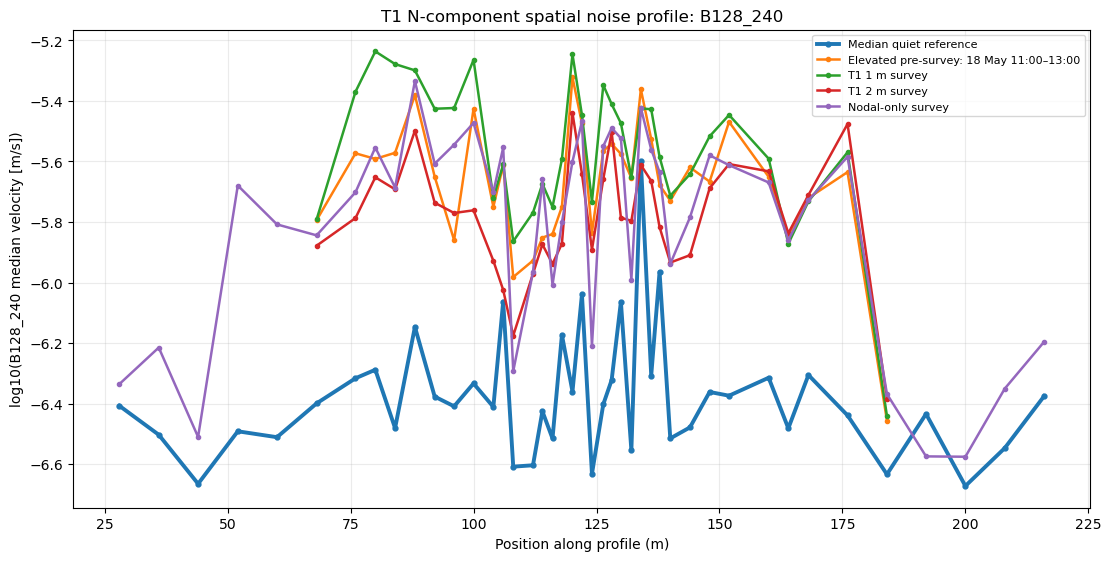

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_rsam_position_codes/noise_profiles/spatial_profiles/T1_N_B128_240_spatial_profiles.png


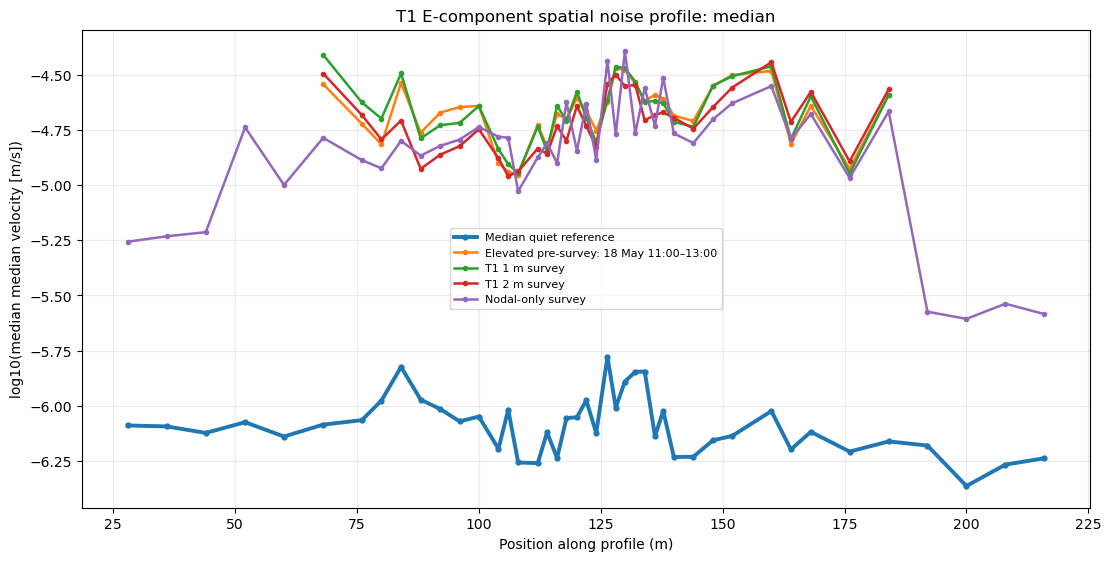

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_rsam_position_codes/noise_profiles/spatial_profiles/T1_E_median_spatial_profiles.png


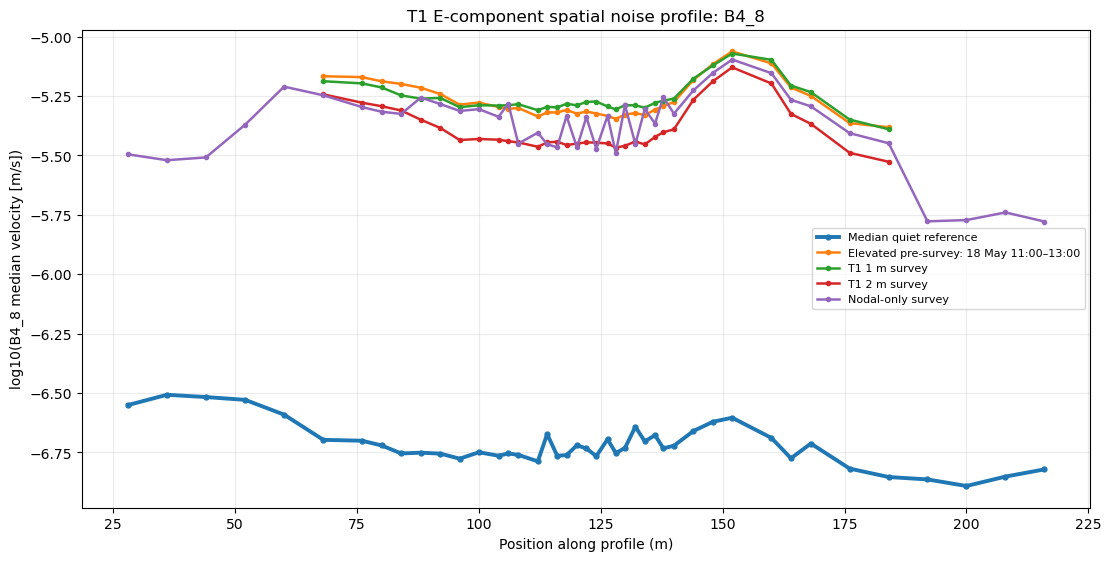

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_rsam_position_codes/noise_profiles/spatial_profiles/T1_E_B4_8_spatial_profiles.png


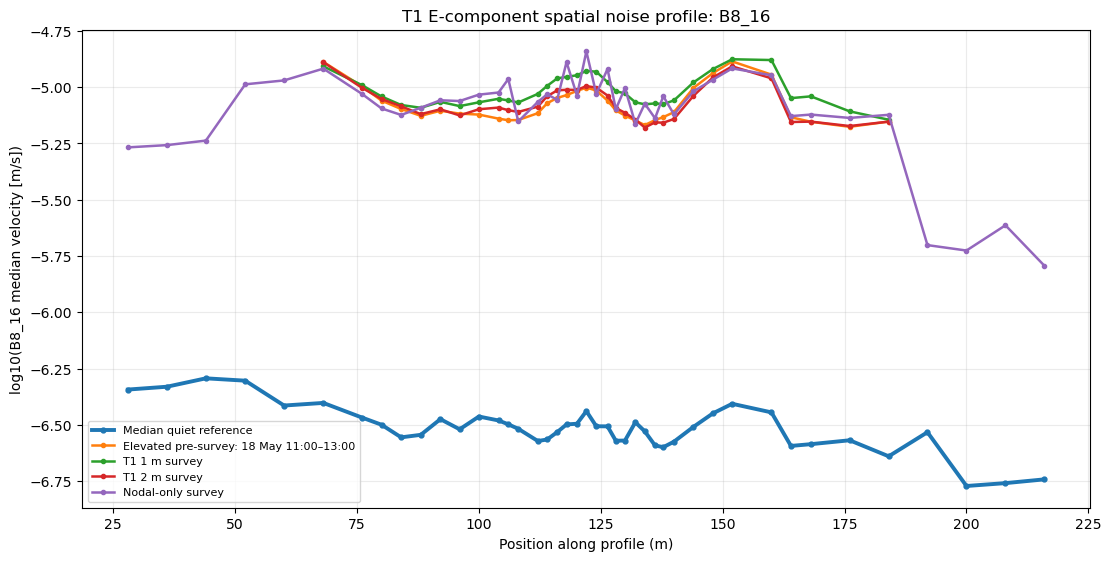

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_rsam_position_codes/noise_profiles/spatial_profiles/T1_E_B8_16_spatial_profiles.png


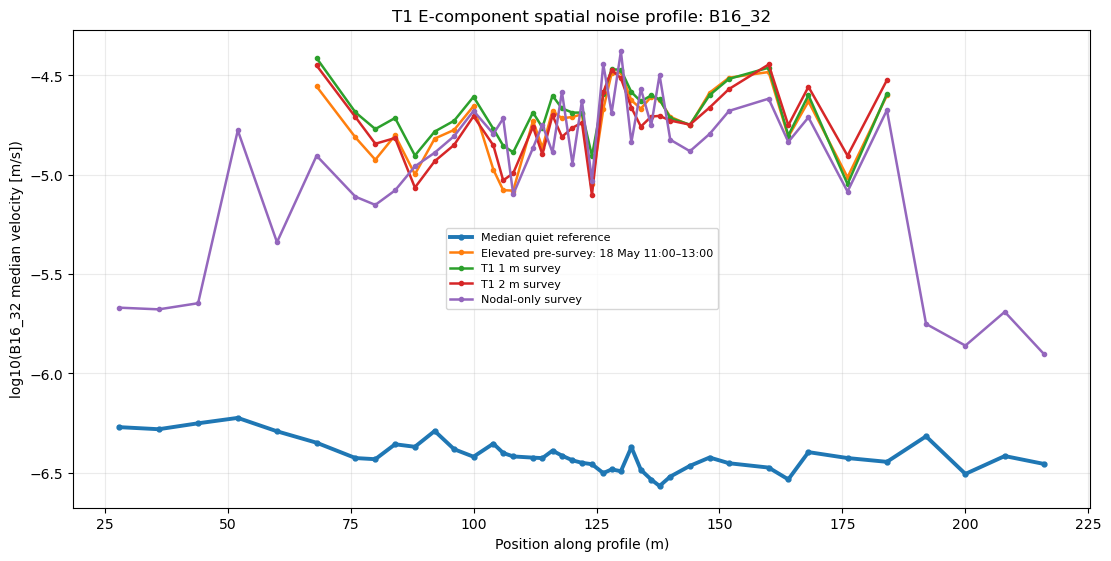

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_rsam_position_codes/noise_profiles/spatial_profiles/T1_E_B16_32_spatial_profiles.png


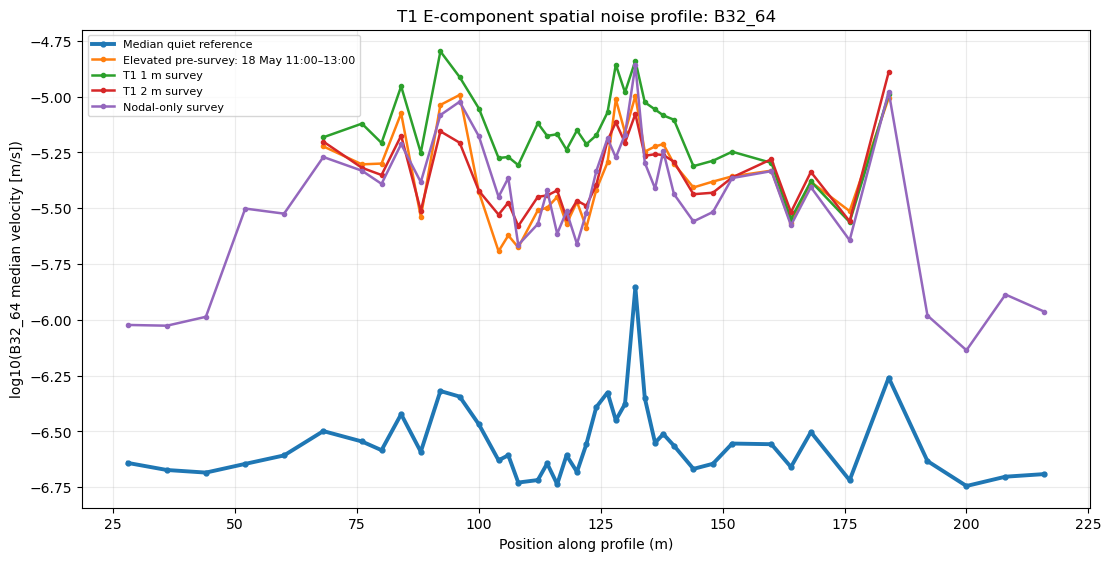

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_rsam_position_codes/noise_profiles/spatial_profiles/T1_E_B32_64_spatial_profiles.png


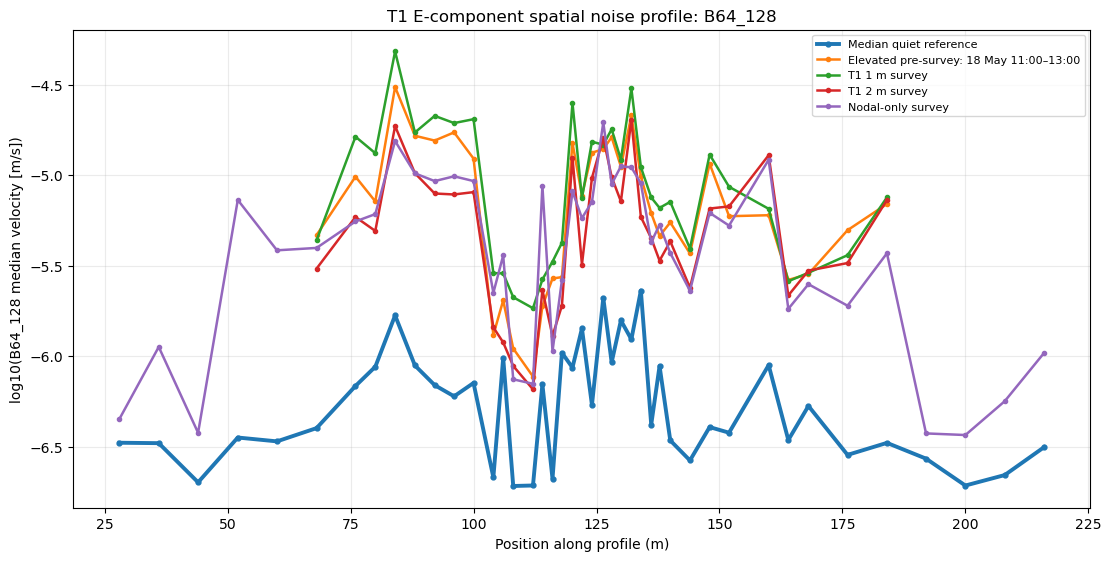

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_rsam_position_codes/noise_profiles/spatial_profiles/T1_E_B64_128_spatial_profiles.png


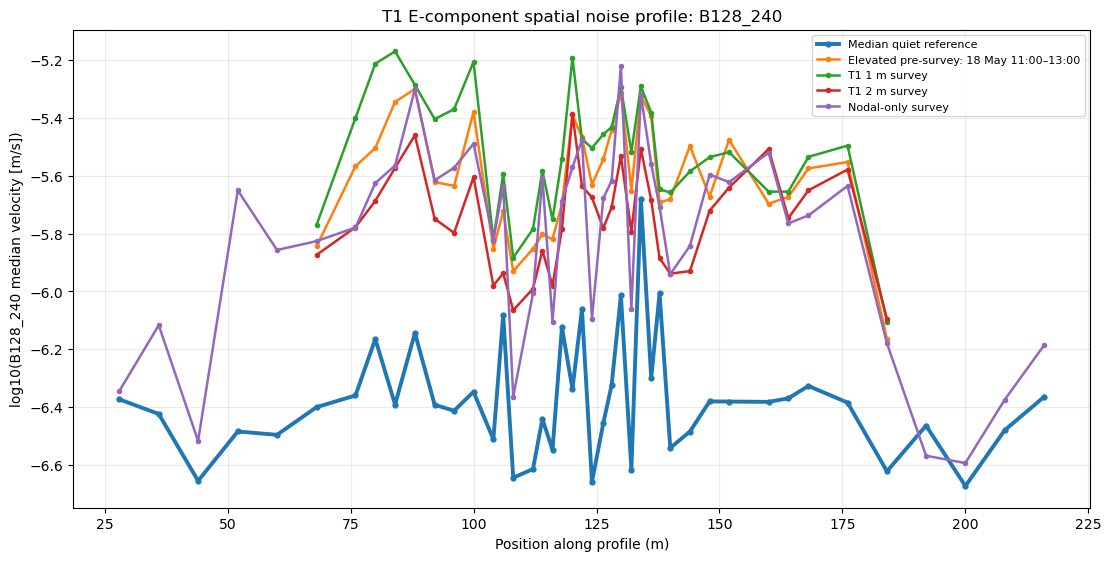

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_rsam_position_codes/noise_profiles/spatial_profiles/T1_E_B128_240_spatial_profiles.png
No quiet reference for T3 Z median
No quiet reference for T3 Z B4_8
No quiet reference for T3 Z B8_16
No quiet reference for T3 Z B16_32
No quiet reference for T3 Z B32_64
No quiet reference for T3 Z B64_128
No quiet reference for T3 Z B128_240
No quiet reference for T3 N median
No quiet reference for T3 N B4_8
No quiet reference for T3 N B8_16
No quiet reference for T3 N B16_32
No quiet reference for T3 N B32_64
No quiet reference for T3 N B64_128
No quiet reference for T3 N B128_240
No quiet reference for T3 E median
No quiet reference for T3 E B4_8
No quiet reference for T3 E B8_16
No quiet reference for T3 E B16_32
No quiet reference for T3 E B32_64
No quiet reference for T3 E B64_128
No quiet reference for T3 E B128_240
Generated 21 profile figures


In [6]:
profile_files = []

for network in NETWORKS:
    for component in COMPONENTS:
        for metric in METRICS:
            outfile = plot_spatial_profile(
                summary,
                network=network,
                component=component,
                metric=metric,
                comparison_periods=COMPARISON_PERIODS,
            )

            if outfile is not None:
                profile_files.append(outfile)

print(f"Generated {len(profile_files)} profile figures")

## Robust amplitude ratios relative to the quiet reference

Ratios are calculated in linear physical units before plotting. Values above
one indicate amplitudes above the median quiet reference at that position.

These are described as period-to-quiet ratios; no causal source is assigned.

In [7]:
def compute_period_to_quiet_ratios(
    summary: pd.DataFrame,
) -> pd.DataFrame:
    rows = []

    group_columns = [
        "network",
        "component",
        "metric",
    ]

    for keys, data in summary.groupby(group_columns):
        network, component, metric = keys
        quiet = build_quiet_reference(data).rename(
            columns={
                "median_velocity_mps": "quiet_velocity_mps"
            }
        )

        if quiet.empty:
            continue

        for period in COMPARISON_PERIODS:
            comparison = profile_for_period(
                data,
                period,
            ).rename(
                columns={
                    "median_velocity_mps": (
                        "comparison_velocity_mps"
                    )
                }
            )

            if comparison.empty:
                continue

            merged = comparison.merge(
                quiet,
                on="position_m",
                how="inner",
            )

            merged["ratio"] = (
                merged["comparison_velocity_mps"]
                / merged["quiet_velocity_mps"]
            )

            merged = merged.replace(
                [np.inf, -np.inf],
                np.nan,
            ).dropna(subset=["ratio"])

            for row in merged.itertuples(index=False):
                rows.append(
                    {
                        "network": network,
                        "component": component,
                        "metric": metric,
                        "period": period,
                        "period_label": PERIOD_LABELS.get(
                            period,
                            period,
                        ),
                        "position_m": row.position_m,
                        "comparison_velocity_mps": (
                            row.comparison_velocity_mps
                        ),
                        "quiet_velocity_mps": (
                            row.quiet_velocity_mps
                        ),
                        "ratio": row.ratio,
                    }
                )

    return pd.DataFrame(rows)


ratio_df = compute_period_to_quiet_ratios(summary)

ratio_file = (
    OUT_DIR
    / "period_to_quiet_ratio_by_position.csv"
)
ratio_df.to_csv(ratio_file, index=False)

print(f"Wrote {ratio_file}")
display(ratio_df.head())

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_rsam_position_codes/noise_profiles/spatial_profiles/period_to_quiet_ratio_by_position.csv


,network,component,metric,period,period_label,position_m,comparison_velocity_mps,quiet_velocity_mps,ratio
0,T1,E,B128_240,elevated_2026-05-18_1100_1300,Elevated pre-survey: 18 May 11:00–13:00,68.09,0.000001,3.975841e-07,3.602391
1,T1,E,B128_240,elevated_2026-05-18_1100_1300,Elevated pre-survey: 18 May 11:00–13:00,76.00,0.000003,4.361824e-07,6.216881
2,T1,E,B128_240,elevated_2026-05-18_1100_1300,Elevated pre-survey: 18 May 11:00–13:00,80.03,0.000003,6.841970e-07,4.584946
3,T1,E,B128_240,elevated_2026-05-18_1100_1300,Elevated pre-survey: 18 May 11:00–13:00,84.05,0.000005,4.057352e-07,11.173256
4,T1,E,B128_240,elevated_2026-05-18_1100_1300,Elevated pre-survey: 18 May 11:00–13:00,88.08,0.000005,7.173788e-07,6.995258


In [8]:
def plot_period_to_quiet_ratio(
    ratio_df: pd.DataFrame,
    *,
    network: str,
    component: str,
    metric: str,
) -> Path | None:
    data = ratio_df[
        (ratio_df["network"] == network)
        & (ratio_df["component"] == component)
        & (ratio_df["metric"] == metric)
    ]

    if data.empty:
        return None

    fig, ax = plt.subplots(
        figsize=FIGSIZE,
        constrained_layout=True,
    )

    for period, group in data.groupby("period"):
        group = group.sort_values("position_m")

        ax.plot(
            group["position_m"],
            group["ratio"],
            linewidth=1.8,
            marker="o",
            markersize=3,
            label=PERIOD_LABELS.get(period, period),
        )

    ax.axhline(
        1.0,
        linewidth=1.0,
        color="0.35",
    )
    ax.set_title(
        f"{network} {component}-component "
        f"period / quiet ratio: {metric}"
    )
    ax.set_xlabel("Position along profile (m)")
    ax.set_ylabel("Amplitude ratio")
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=8)

    outfile = (
        OUT_DIR
        / f"{network}_{component}_{metric}_period_to_quiet_ratio.png"
    )
    fig.savefig(
        outfile,
        dpi=DPI,
        bbox_inches="tight",
    )
    plt.show()
    plt.close(fig)

    print(f"Wrote {outfile}")
    return outfile

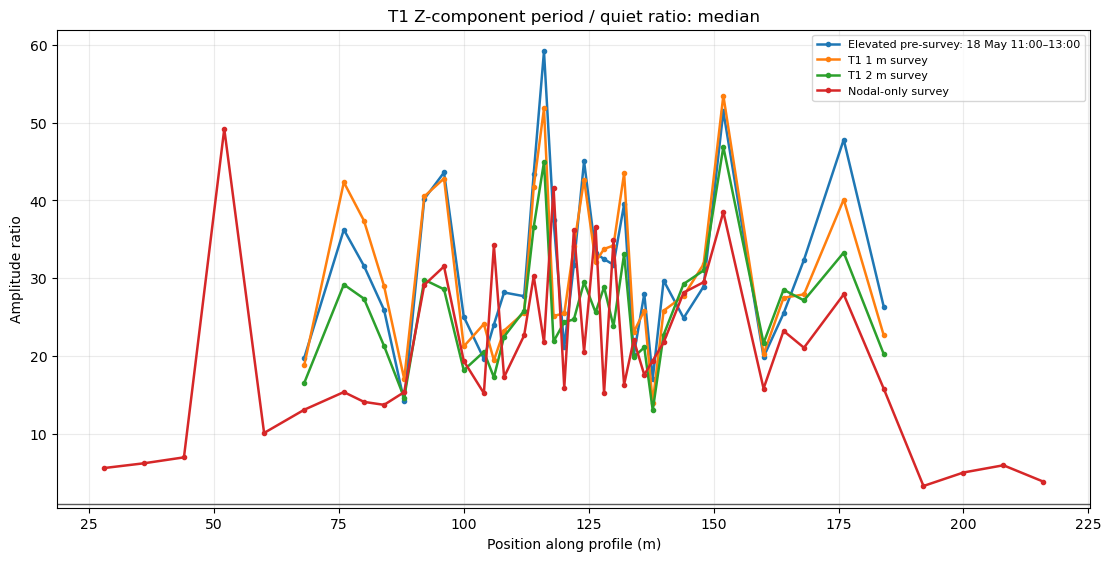

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_rsam_position_codes/noise_profiles/spatial_profiles/T1_Z_median_period_to_quiet_ratio.png


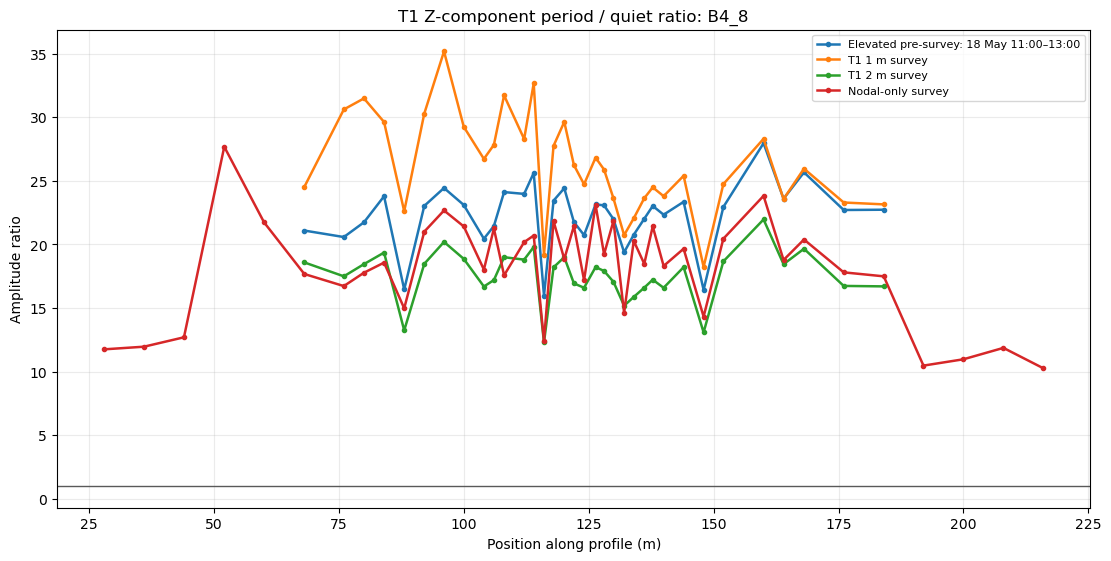

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_rsam_position_codes/noise_profiles/spatial_profiles/T1_Z_B4_8_period_to_quiet_ratio.png


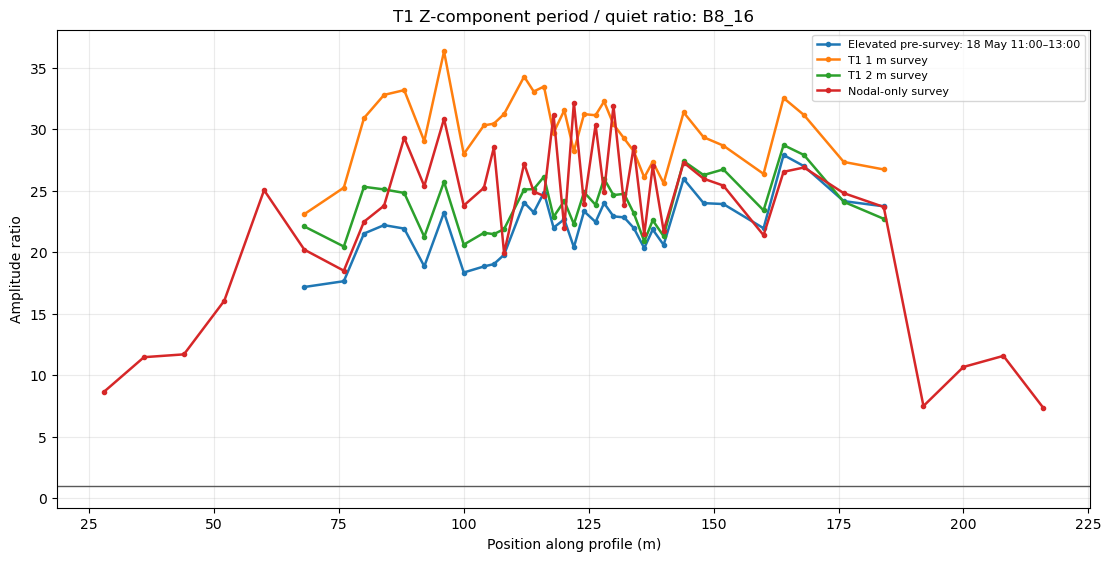

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_rsam_position_codes/noise_profiles/spatial_profiles/T1_Z_B8_16_period_to_quiet_ratio.png


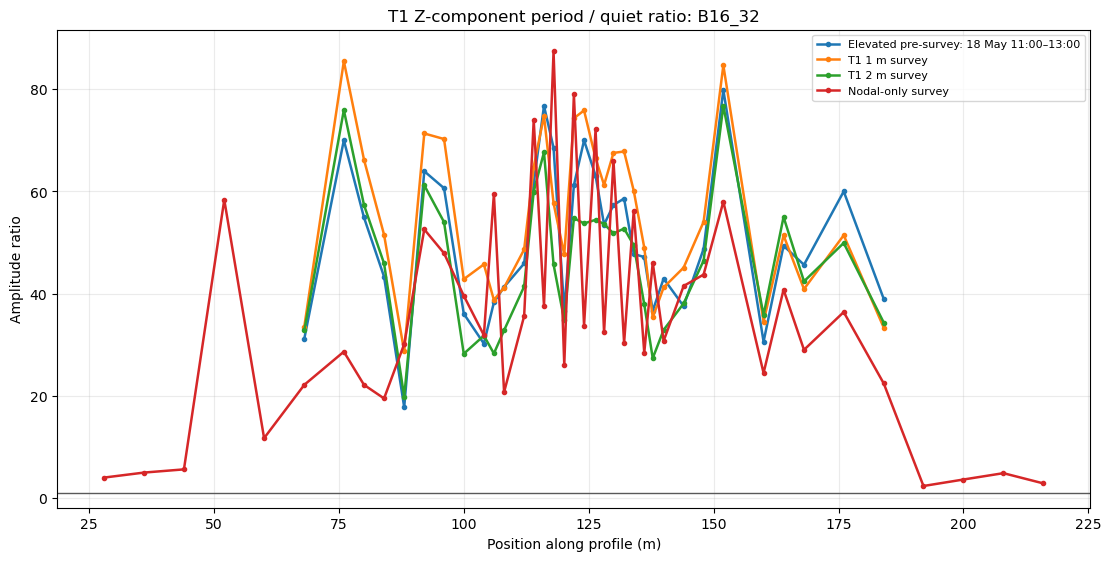

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_rsam_position_codes/noise_profiles/spatial_profiles/T1_Z_B16_32_period_to_quiet_ratio.png


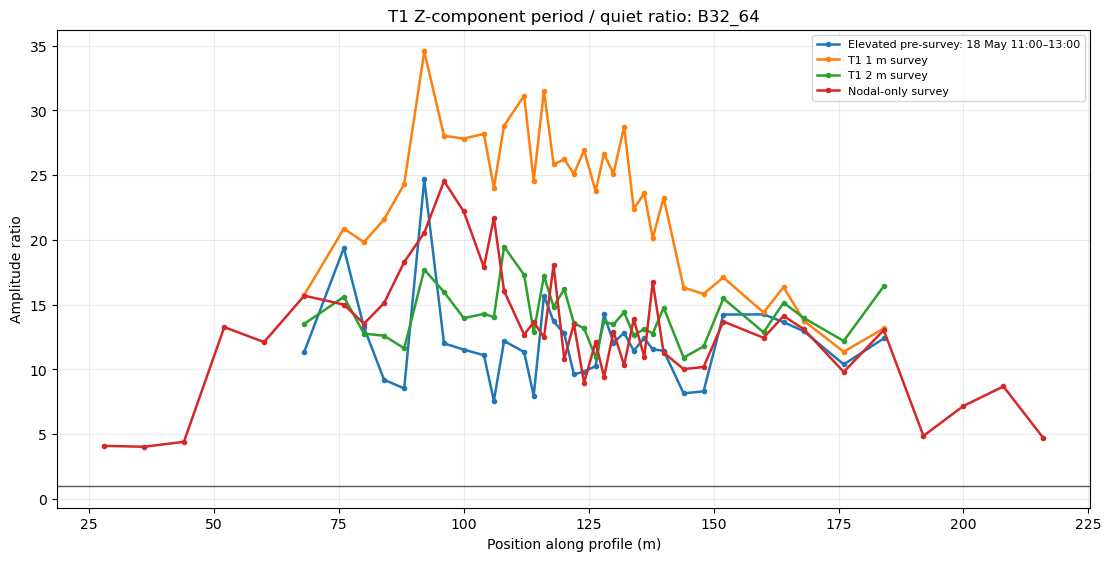

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_rsam_position_codes/noise_profiles/spatial_profiles/T1_Z_B32_64_period_to_quiet_ratio.png


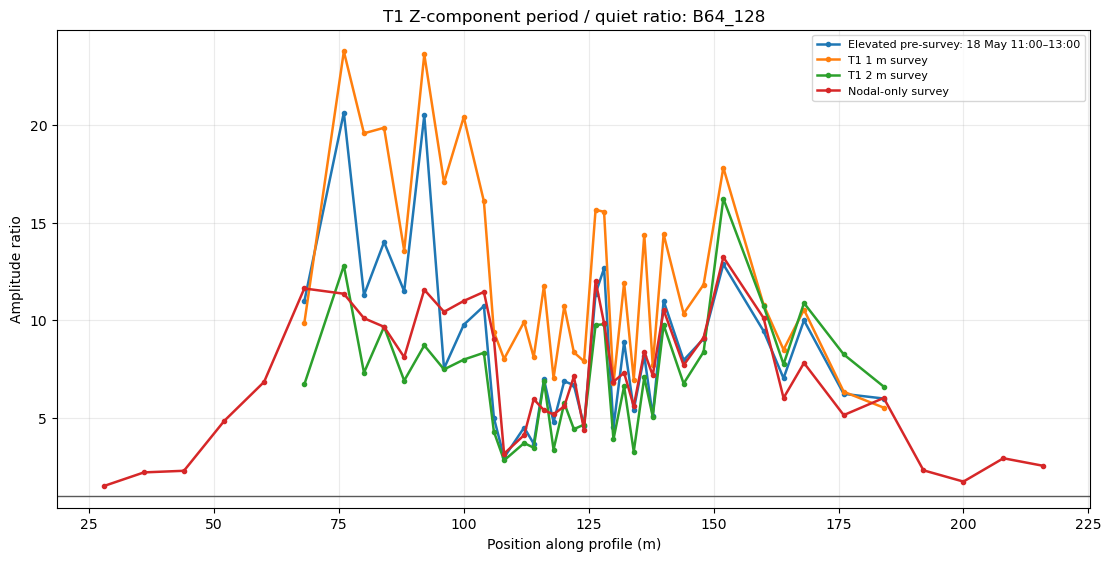

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_rsam_position_codes/noise_profiles/spatial_profiles/T1_Z_B64_128_period_to_quiet_ratio.png


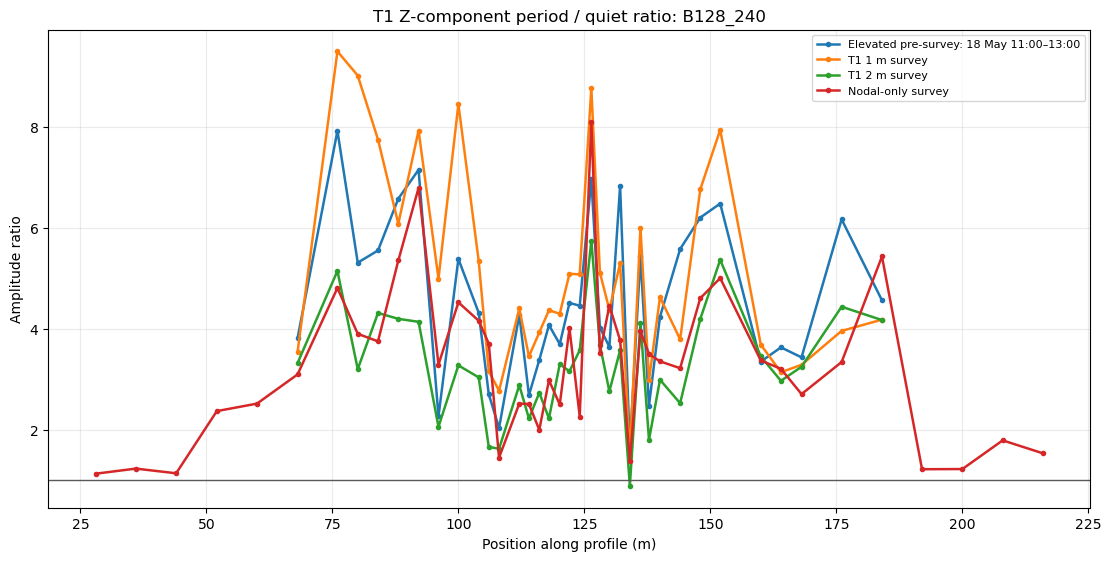

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_rsam_position_codes/noise_profiles/spatial_profiles/T1_Z_B128_240_period_to_quiet_ratio.png


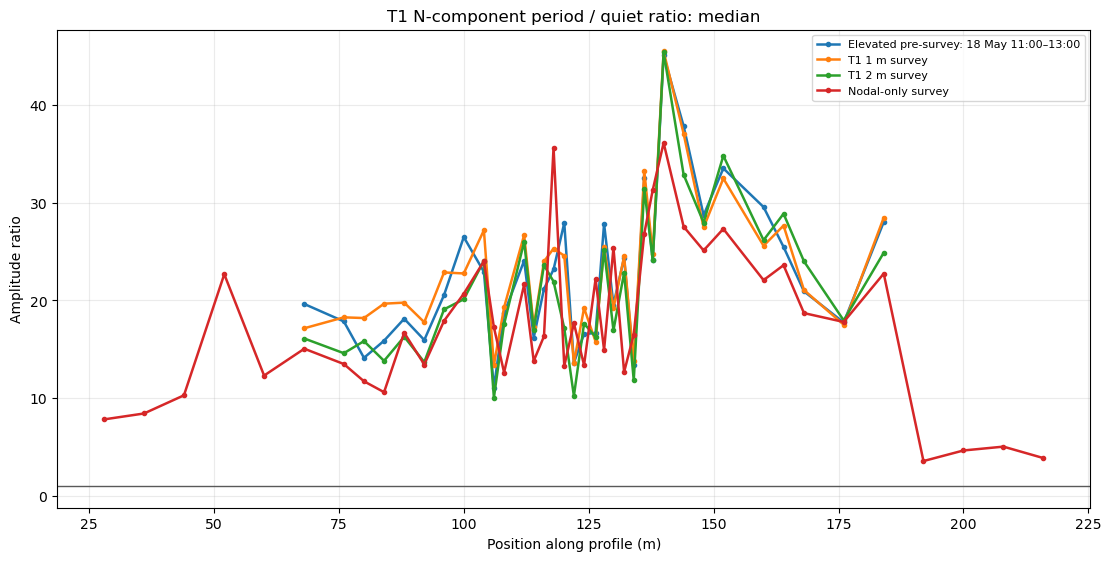

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_rsam_position_codes/noise_profiles/spatial_profiles/T1_N_median_period_to_quiet_ratio.png


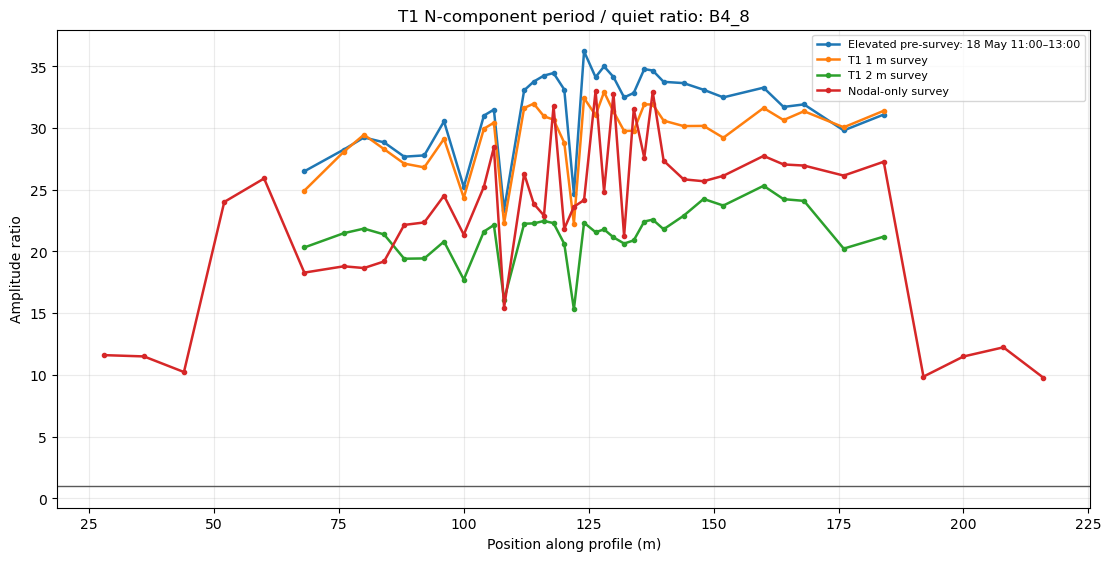

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_rsam_position_codes/noise_profiles/spatial_profiles/T1_N_B4_8_period_to_quiet_ratio.png


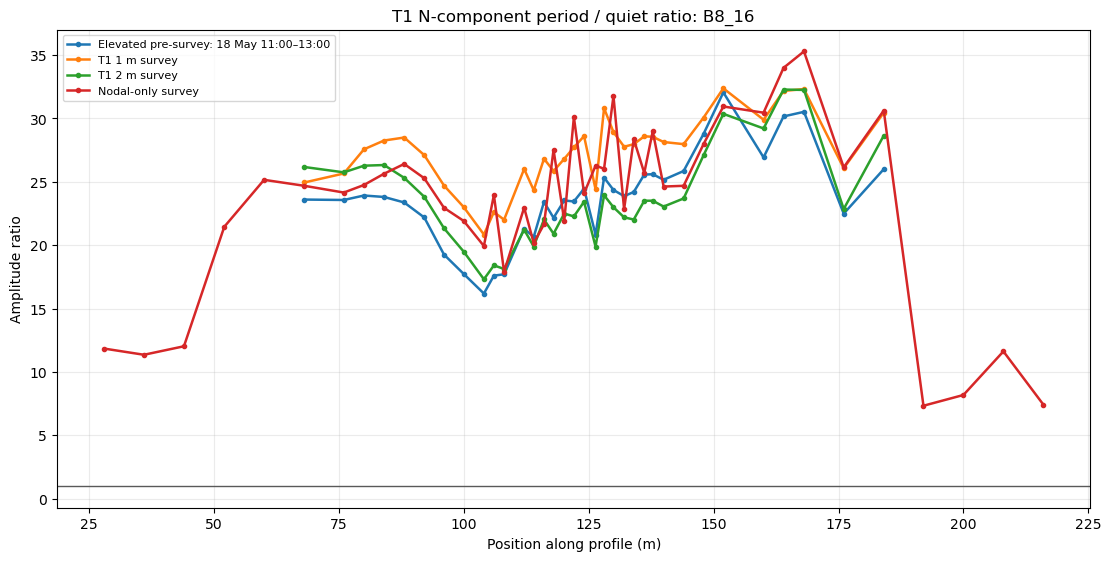

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_rsam_position_codes/noise_profiles/spatial_profiles/T1_N_B8_16_period_to_quiet_ratio.png


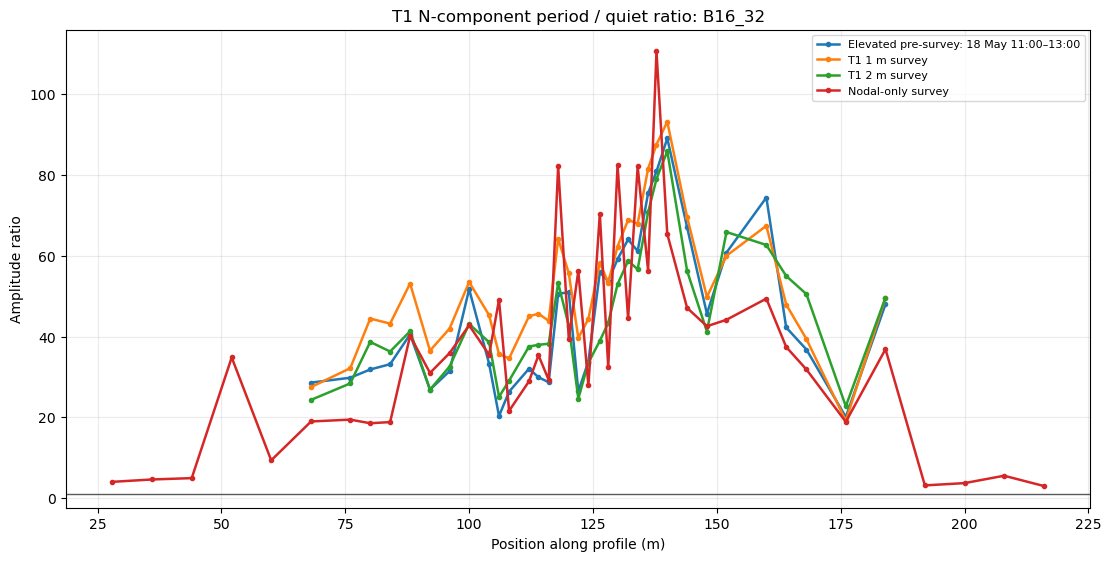

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_rsam_position_codes/noise_profiles/spatial_profiles/T1_N_B16_32_period_to_quiet_ratio.png


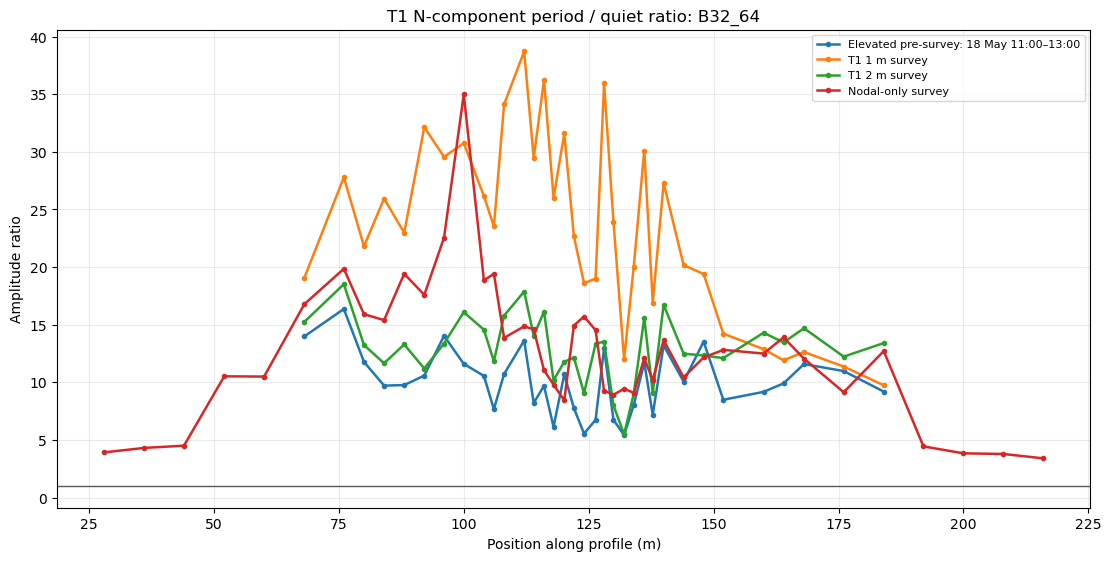

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_rsam_position_codes/noise_profiles/spatial_profiles/T1_N_B32_64_period_to_quiet_ratio.png


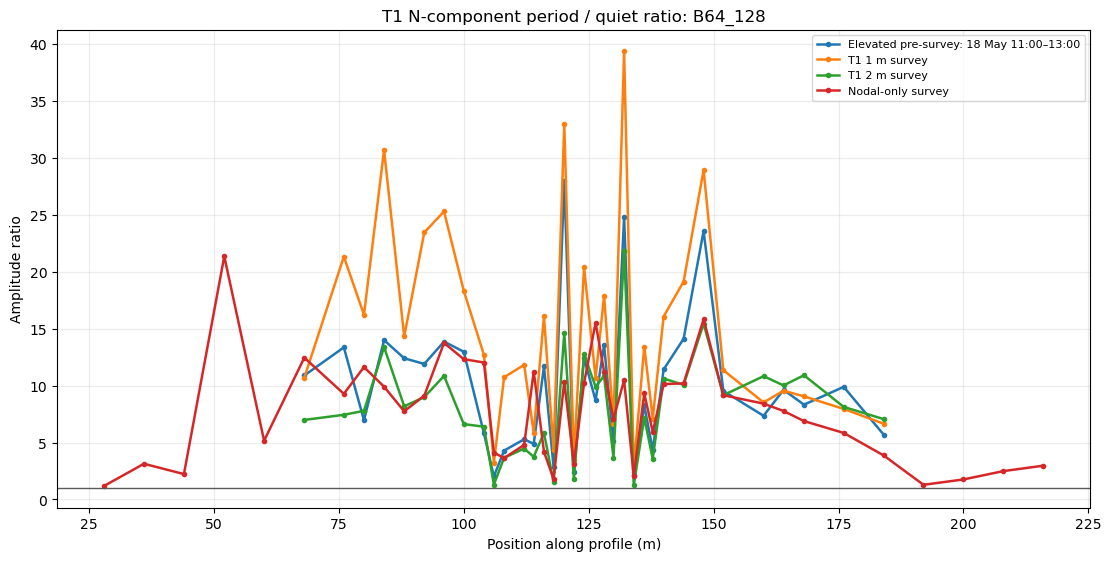

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_rsam_position_codes/noise_profiles/spatial_profiles/T1_N_B64_128_period_to_quiet_ratio.png


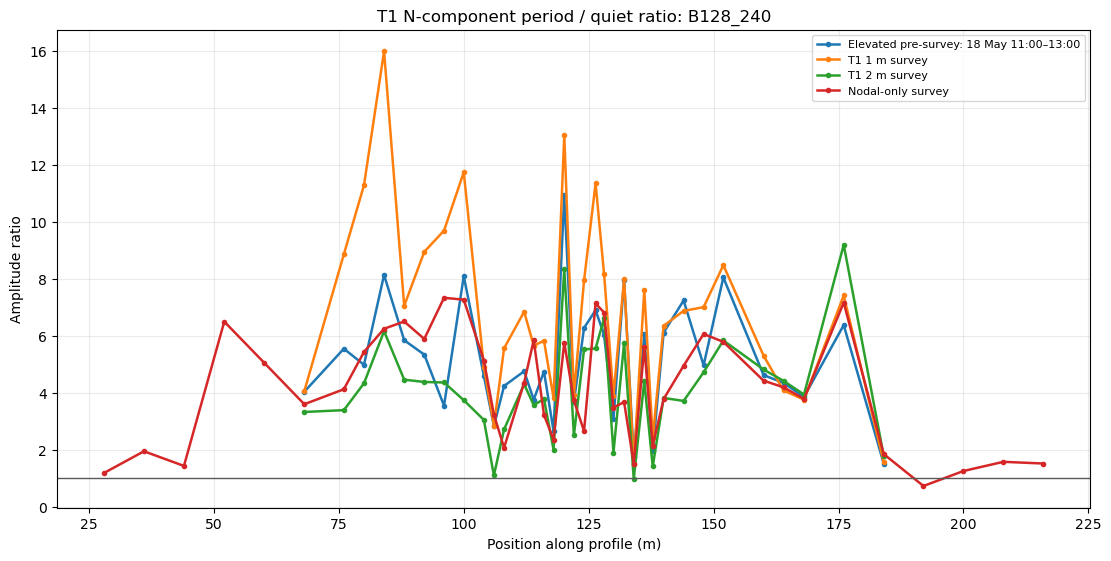

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_rsam_position_codes/noise_profiles/spatial_profiles/T1_N_B128_240_period_to_quiet_ratio.png


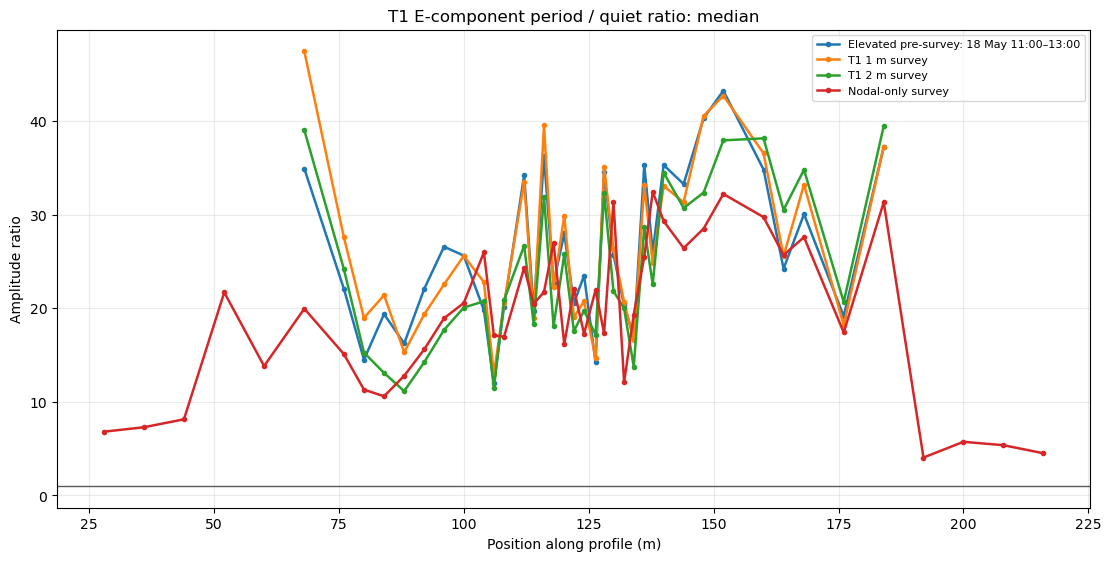

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_rsam_position_codes/noise_profiles/spatial_profiles/T1_E_median_period_to_quiet_ratio.png


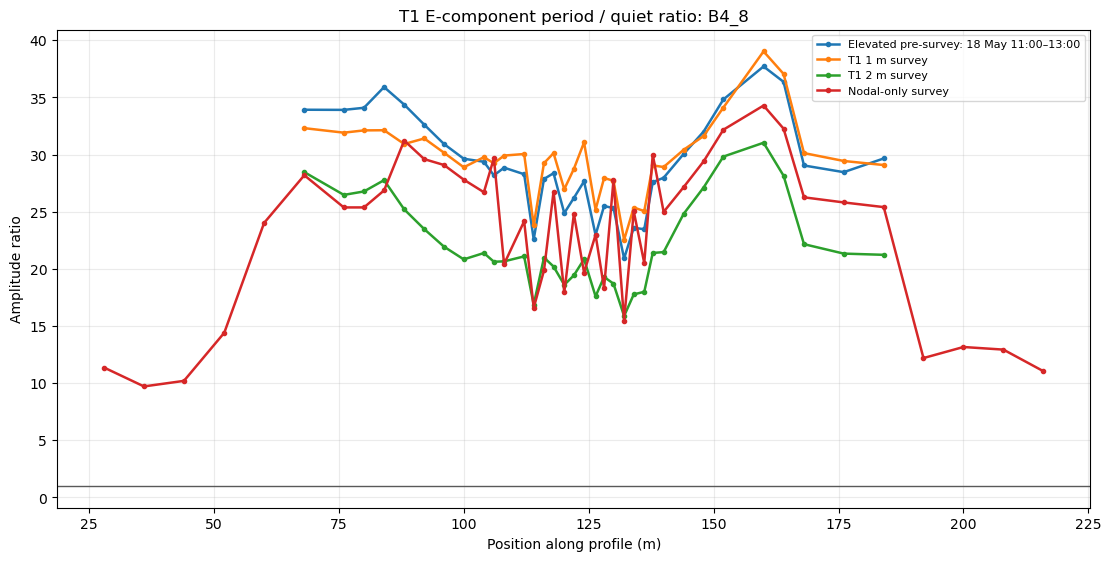

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_rsam_position_codes/noise_profiles/spatial_profiles/T1_E_B4_8_period_to_quiet_ratio.png


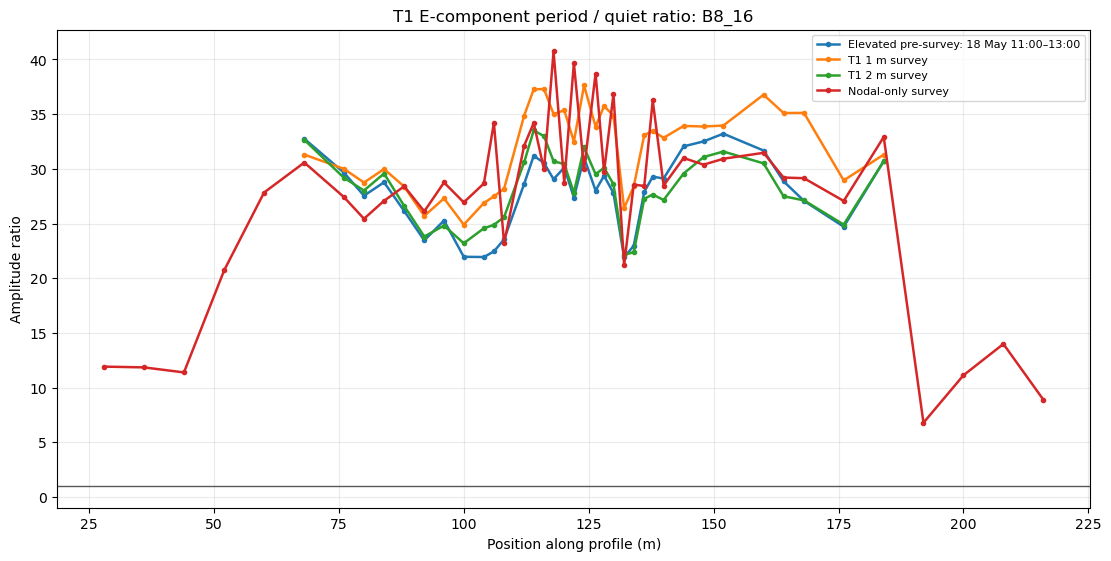

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_rsam_position_codes/noise_profiles/spatial_profiles/T1_E_B8_16_period_to_quiet_ratio.png


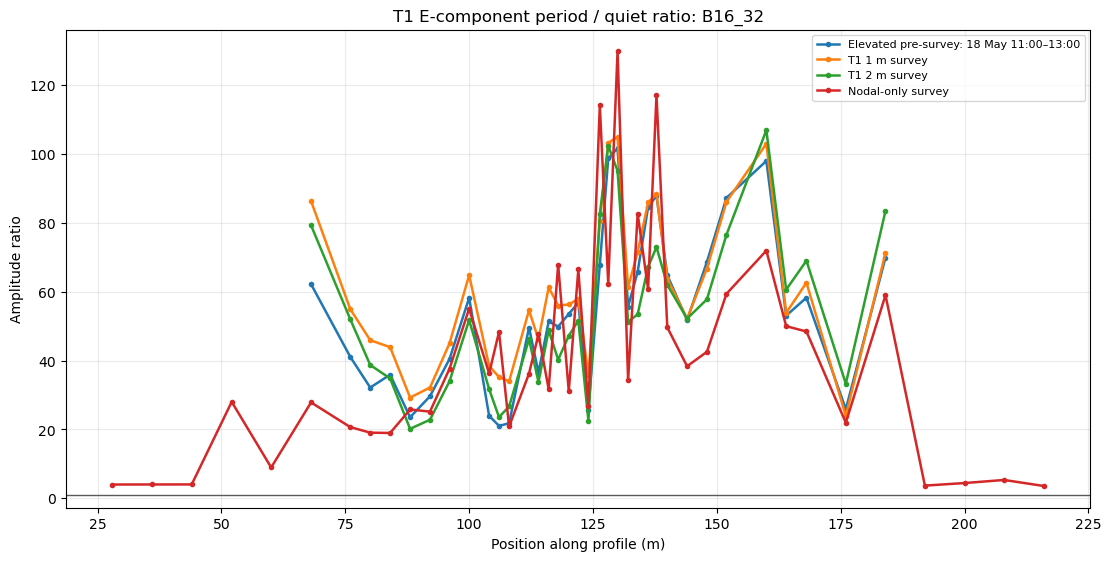

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_rsam_position_codes/noise_profiles/spatial_profiles/T1_E_B16_32_period_to_quiet_ratio.png


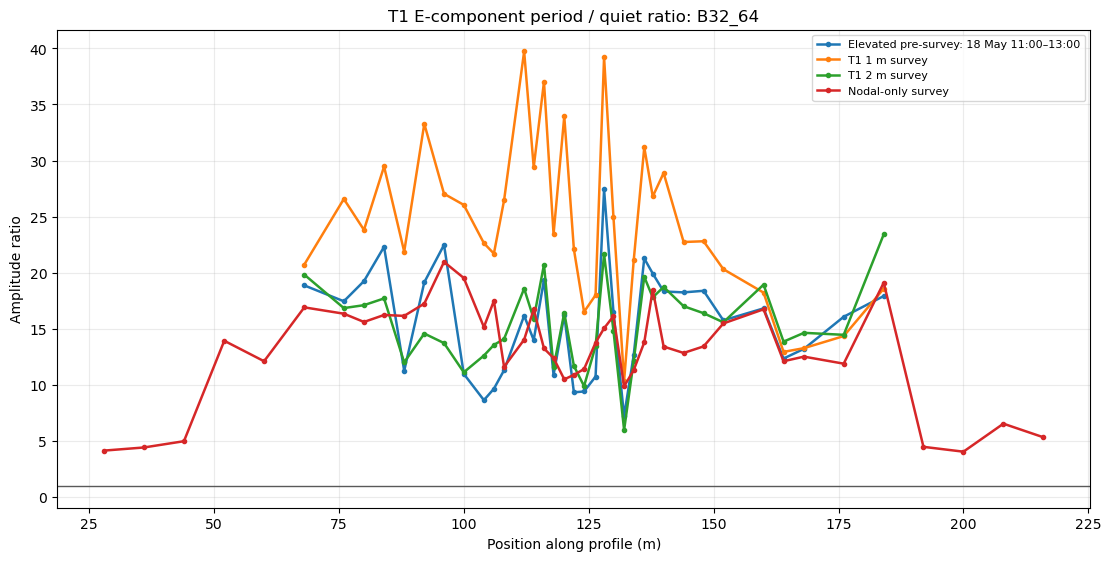

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_rsam_position_codes/noise_profiles/spatial_profiles/T1_E_B32_64_period_to_quiet_ratio.png


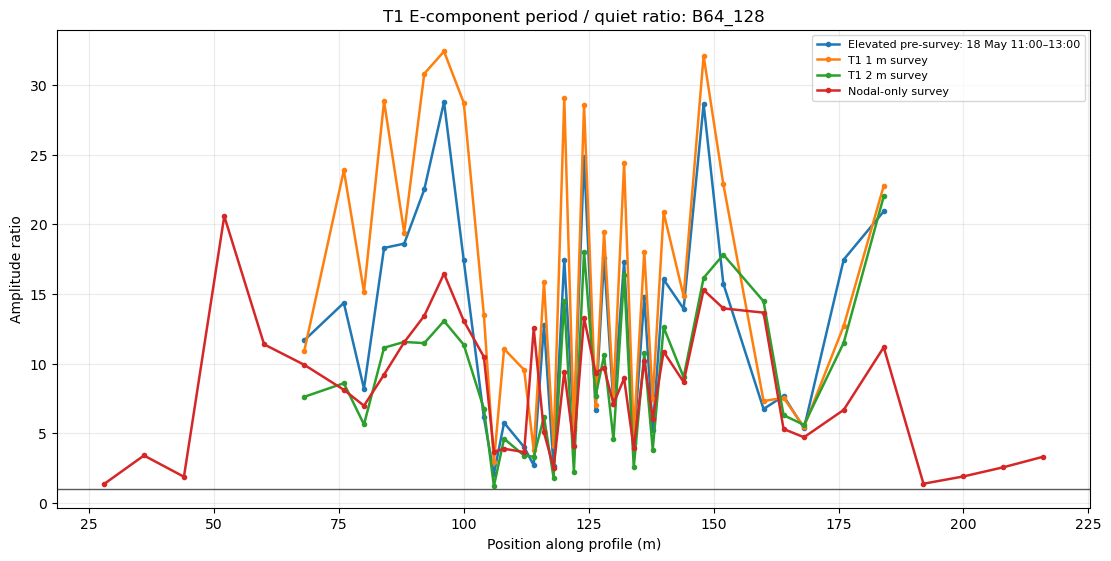

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_rsam_position_codes/noise_profiles/spatial_profiles/T1_E_B64_128_period_to_quiet_ratio.png


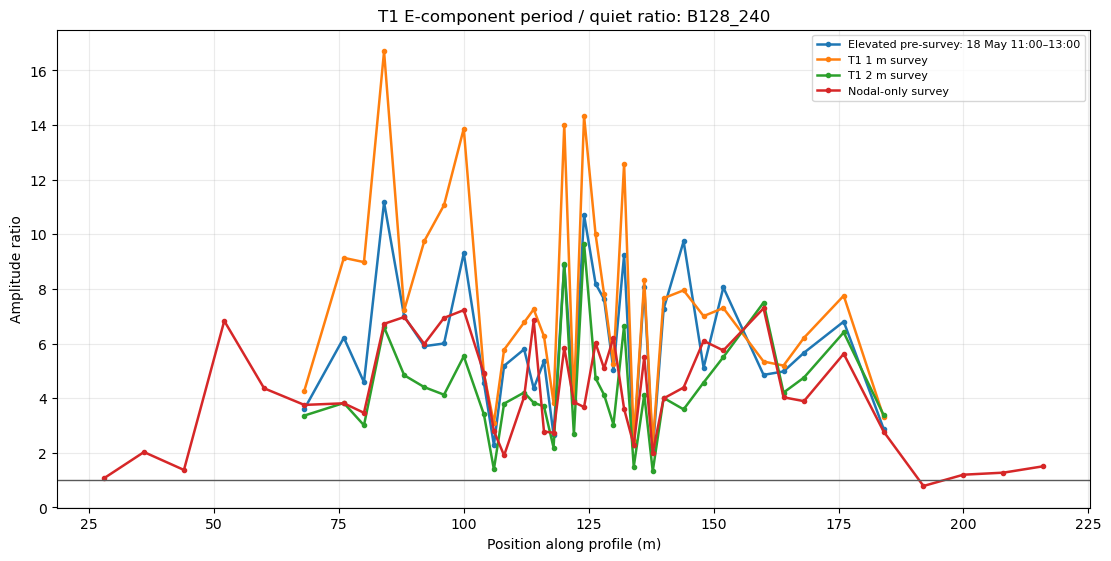

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_rsam_position_codes/noise_profiles/spatial_profiles/T1_E_B128_240_period_to_quiet_ratio.png
Generated 21 ratio figures


In [9]:
ratio_plot_files = []

for network in NETWORKS:
    for component in COMPONENTS:
        for metric in METRICS:
            outfile = plot_period_to_quiet_ratio(
                ratio_df,
                network=network,
                component=component,
                metric=metric,
            )

            if outfile is not None:
                ratio_plot_files.append(outfile)

print(
    f"Generated {len(ratio_plot_files)} ratio figures"
)

## Diagnostics

In [10]:
display(
    summary
    .groupby(
        [
            "network",
            "location",
            "component",
            "metric",
            "period",
        ]
    )
    .agg(
        positions=("position_m", "nunique"),
        minimum_position_m=("position_m", "min"),
        maximum_position_m=("position_m", "max"),
    )
    .reset_index()
)

display(
    ratio_df
    .groupby(
        [
            "network",
            "component",
            "metric",
            "period",
        ]
    )["ratio"]
    .agg(["count", "median", "min", "max"])
    .reset_index()
)

,network,location,component,metric,period,positions,minimum_position_m,maximum_position_m
0,T1,N1,E,B128_240,quiet_2026-05-17_0400_0800,35,28.0,216.0
1,T1,N1,E,B16_32,quiet_2026-05-17_0400_0800,35,28.0,216.0
2,T1,N1,E,B32_64,quiet_2026-05-17_0400_0800,35,28.0,216.0
3,T1,N1,E,B4_8,quiet_2026-05-17_0400_0800,35,28.0,216.0
4,T1,N1,E,B64_128,quiet_2026-05-17_0400_0800,35,28.0,216.0
...,...,...,...,...,...,...,...,...
184,T3,N4,Z,B32_64,survey_nodal_only,35,0.5,68.5
185,T3,N4,Z,B4_8,survey_nodal_only,35,0.5,68.5
186,T3,N4,Z,B64_128,survey_nodal_only,35,0.5,68.5
187,T3,N4,Z,B8_16,survey_nodal_only,35,0.5,68.5


,network,component,metric,period,count,median,min,max
0,T1,E,B128_240,elevated_2026-05-18_1100_1300,34,5.728435,2.064050,11.173256
1,T1,E,B128_240,survey_T1_1m,34,7.241714,2.291247,16.696820
2,T1,E,B128_240,survey_T1_2m,34,4.127581,1.324538,9.661549
3,T1,E,B128_240,survey_nodal_only,43,3.993460,0.786727,7.291956
4,T1,E,B16_32,elevated_2026-05-18_1100_1300,34,53.277787,21.032236,101.625884
...,...,...,...,...,...,...,...,...
79,T1,Z,B8_16,survey_nodal_only,43,24.586874,7.344083,32.174143
80,T1,Z,median,elevated_2026-05-18_1100_1300,34,29.302198,14.146738,59.155925
81,T1,Z,median,survey_T1_1m,34,27.813157,13.979916,53.475674
82,T1,Z,median,survey_T1_2m,34,25.146045,13.005487,46.870427
